In [1]:
# limit the thread used by numpy for better parallelization
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [2]:
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    print("no cupy ")
from scipy.signal import windows 

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.Interferometer import *
from Triangle.TDI import *
from Triangle.Glitch import *
from Triangle.GW import *
from Triangle.Cosmology import LuminosityDistance, z_dl

import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

# import multiprocessing
# if __name__ == "__main__":
#     multiprocessing.set_start_method("fork")
# print("number of cpus =", multiprocessing.cpu_count())
# pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())

no cupy 


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [ ]:
class TDIFlyInitializer:
    
    X2_strings = {
        "12": [(1.0, []), (-1.0, ["13", "31"]), (-1.0, ["13", "31", "12", "21"]), (1.0, ["12", "21", "13", "31", "13", "31"])],
        "23": [],
        "31": [(-1.0, ["13"]), (1.0, ["12", "21", "13"]), (1.0, ["12", "21", "13", "31", "13"]), (-1.0, ["13", "31", "12", "21", "12", "21", "13"])],
        "21": [(1.0, ["12"]), (-1.0, ["13", "31", "12"]), (-1.0, ["13", "31", "12", "21", "12"]), (1.0, ["12", "21", "13", "31", "13", "31", "12"])],
        "32": [],
        "13": [(-1.0, []), (1.0, ["12", "21"]), (1.0, ["12", "21", "13", "31"]), (-1.0, ["13", "31", "12", "21", "12", "21"])],
    }

    def __init__(self, orbit, Pstring, tcb_times, Nsparse=512, use_gpu=False):
        """
        Args:
            orbit: an Orbit object
            Pstring: a string specifying the TDI channel
            tcb_times: TCB times at which the TDI responses will be calculated, **NOTE** should be uniformly spaced for frequency-domain calculation
            Nsparse: number sparse time-domain samples
        """
        self.orbit_object = orbit
        self.tcb_times = tcb_times.copy()
        self.Ntime = len(tcb_times)
        self.dt = self.tcb_times[1] - self.tcb_times[0]
        self.Tobs = self.Ntime * self.dt
        self.Nsparse = int(Nsparse)
        self.drop_points = drop_points
        
        if use_gpu:
            self.xp = xp
        else:
            self.xp = np
        self.COS = self.xp.cos 
        self.SIN = self.xp.sin 
        self.EXP = self.xp.exp 
        self.SINC = self.xp.sinc
        self.MATMUL = self.xp.matmul
        self.NX = self.xp.newaxis

        # the orbit functions use numpy array as input
        self.sparse_times = np.linspace(tcb_times[0], tcb_times[0]+self.Tobs, num=Nsparse, endpoint=False) # (Nsparse) ensure the same Tobs 
        self.sparse_dt = self.sparse_times[1] - self.sparse_times[0] 
        self.sparse_t0 = self.sparse_times[0]
        self.sparse_tf = self.sparse_times[-1]

        # calculate sparsely sampled time series associated with orbit and time delays
        self.Ndelay_dict = {}  # each item is an integer
        for key in MOSA_labels:
            self.Ndelay_dict[key] = len(Pstring[key])

        self.delay_factor_dict = {}  # each item is a xp array of shape (Ndelay)
        for key in MOSA_labels:
            self.delay_factor_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delay_factor_dict[key].append(Pstring[key][Idelay][0])
            self.delay_factor_dict[key] = self.xp.array(self.delay_factor_dict[key])

        self.delay_dict = {}  # each item is a numpy array of shape (Ndelay, Nsparse), not converted to xp array yet 
        for key in MOSA_labels:
            self.delay_dict[key] = []
            Pij = Pstring[key]
            for Idelay in range(self.Ndelay_dict[key]):
                d_Idelay = np.zeros_like(self.sparse_times)
                N_single_delay = len(Pij[Idelay][1])
                for I_single_delay in range(N_single_delay): # nested delay is not necessary
                    if Pij[Idelay][1][I_single_delay][0] == "-":
                        d_Idelay += -orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay][1:]](self.sparse_times)
                    else:
                        d_Idelay += orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay]](self.sparse_times)
                self.delay_dict[key].append(d_Idelay)

        self.delayed_dij_dict = {}  # dij delayed by d_Idelay, each item is a xp array of shape (Ndelay, Nsparse)
        for key in MOSA_labels:
            self.delayed_dij_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_dij_dict[key].append(orbit.LTTfunctions()[key](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_dij_dict[key] = self.xp.array(self.delayed_dij_dict[key])

        # calculate time series associated with orbit
        self.arm_vector_dict = assign_function_for_MOSAs(
            functions=orbit.ArmVectorfunctions(),
            proper_time=self.sparse_times,
        )  # each item is a xp array of shape (Nsparse, 3)
        for key in MOSA_labels:
            self.arm_vector_dict[key] = self.xp.array(self.arm_vector_dict[key])

        self.delayed_send_position_vector_dict = {}  # positions of sending SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
        for key in MOSA_labels:
            self.delayed_send_position_vector_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_send_position_vector_dict[key].append(orbit.Positionfunctions()[key[1]](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_send_position_vector_dict[key] = self.xp.array(self.delayed_send_position_vector_dict[key])

        self.delayed_recv_position_vector_dict = {}  # positions of receiving SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
        for key in MOSA_labels:
            self.delayed_recv_position_vector_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_recv_position_vector_dict[key].append(orbit.Positionfunctions()[key[0]](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_recv_position_vector_dict[key] = self.xp.array(self.delayed_recv_position_vector_dict[key])

        # convert delay dict to xp array at last since it is used in the calculation of other dicts
        for key in MOSA_labels:
            self.delay_dict[key] = self.xp.array(self.delay_dict[key])
            
        # convert sparse sample times to xp array and calculate its powers 
        self.sparse_times = self.xp.array(self.sparse_times, dtype=self.xp.float64)
        self.sparse_times2 = self.sparse_times ** 2 
        self.sparse_times3 = self.sparse_times ** 3 
        self.tcb_times = self.xp.array(self.tcb_times)

    def vectorized_interp(self, x, xp0, xpf, dxp, xp, fp):
        """ 
        Args: 
            x: numpy or cupy array of shape (N) 
            xp0, xpf, dxp: initial, final values and sampling interval for a **uniformly sampled** xp series 
            xp: numpy or cupy array of shape (M) 
            fp: numpy or cupy array of shape (K, M)
        Returns:
            numpy or cupy array of shape (K, N)
        """
        # search the location of x in xp 
        # indices = self.xp.searchsorted(xp, x, side='right') - 1
        # indices = self.xp.floor((x - xp0) / dxp).astype(self.xp.int32)
        indices = ((x - xp0) / dxp).astype(self.xp.int32)
        indices = self.xp.clip(indices, 0, len(xp) - 2)
        
        # calculate weights for linear interpolation 
        x_left = xp[indices]
        x_right = xp[indices + 1]
        weights = (x - x_left) / (x_right - x_left)
        
        # get functon values at the left and right 
        fp_left = fp[:, indices]  
        fp_right = fp[:, indices + 1]  
        
        # calculate linear interpolation 
        result = fp_left + weights * (fp_right - fp_left)
        
        # deal with boundaries 
        below_mask = x < xp0 
        above_mask = x > xpf 
        result[:, below_mask] = fp[:, 0, self.NX]
        result[:, above_mask] = fp[:, -1, self.NX]
        return result

In [4]:
class TDIFlyGB(TDIFly):
    def __init__(self, orbit, Pstring, tcb_times, Nsparse=512, drop_points=0, use_gpu=False):
        super().__init__(orbit, Pstring, tcb_times, Nsparse, drop_points, use_gpu)

    def __call__(self, parameters, domain="time"):
        """
        Args:
            parameters: a dictionary storing the source parameters. Each parameter can be either a numpy array or a float number 
            domain: "time" or "frequency"
        Returns:
            the time series of TDI responses
        """
        A = self.xp.atleast_1d(parameters["A"]) # xp array of shape (Nevents)
        f0 = self.xp.atleast_1d(parameters["f0"])
        fdot0 = self.xp.atleast_1d(parameters["fdot0"])
        fddot0 = self.get_fddot(f=f0, fdot=fdot0)
        phase0 = self.xp.atleast_1d(parameters["phase0"])
        inclination = self.xp.atleast_1d(parameters["inclination"])
        longitude = self.xp.atleast_1d(parameters["longitude"])
        latitude = self.xp.atleast_1d(parameters["latitude"])
        psi = self.xp.atleast_1d(parameters["psi"])

        Nevents = len(A)
        
        # wave vectors 
        k = -self.xp.array([self.COS(latitude) * self.COS(longitude), self.COS(latitude) * self.SIN(longitude), self.SIN(latitude)]).T # (Nevents, 3)
        u = self.xp.array([self.SIN(longitude), -self.COS(longitude), self.xp.zeros(Nevents)]).T # (Nevents, 3)
        v = self.xp.array([-self.SIN(latitude) * self.COS(longitude), -self.SIN(latitude) * self.SIN(longitude), self.COS(latitude)]).T # (Nevents, 3)
        
        # arm projections 
        un12 = self.MATMUL(u, self.arm_vector_dict["12"].T) # (Nevents, Nsparse)
        un23 = self.MATMUL(u, self.arm_vector_dict["23"].T)
        un31 = self.MATMUL(u, self.arm_vector_dict["31"].T)
        vn12 = self.MATMUL(v, self.arm_vector_dict["12"].T) 
        vn23 = self.MATMUL(v, self.arm_vector_dict["23"].T)
        vn31 = self.MATMUL(v, self.arm_vector_dict["31"].T)
        
        # pattern functions in the SSB frame 
        xiplus12 = un12 ** 2 - vn12 ** 2 # (Nevents, Nsparse), xi_ij = xi_ji
        xiplus23 = un23 ** 2 - vn23 ** 2
        xiplus31 = un31 ** 2 - vn31 ** 2
        xicross12 = 2. * un12 * vn12
        xicross23 = 2. * un23 * vn23
        xicross31 = 2. * un31 * vn31 
        
        # pattern functions in the source frame 
        cos2psi = self.COS(2. * psi)[:, self.NX] # (Nevents, 1)
        sin2psi = self.SIN(2. * psi)[:, self.NX]
        zetaplus12 = cos2psi * xiplus12 + sin2psi * xicross12 # (Nevents, Nsparse)
        zetaplus23 = cos2psi * xiplus23 + sin2psi * xicross23
        zetaplus31 = cos2psi * xiplus31 + sin2psi * xicross31 
        zetacross12 = -sin2psi * xiplus12 + cos2psi * xicross12
        zetacross23 = -sin2psi * xiplus23 + cos2psi * xicross23
        zetacross31 = -sin2psi * xiplus31 + cos2psi * xicross31 
        zetaplus = {
                "12": zetaplus12,  # (Nevents, Nsparse)
                "23": zetaplus23, 
                "31": zetaplus31, 
                "21": zetaplus12, 
                "32": zetaplus23, 
                "13": zetaplus31 
            }
        zetacross = {
                "12": zetacross12, 
                "23": zetacross23, 
                "31": zetacross31, 
                "21": zetacross12, 
                "32": zetacross23, 
                "13": zetacross31 
            }
        
        # the knij terms 
        kn = dict() 
        for key in MOSA_labels: 
            kn[key] = self.MATMUL(k, self.arm_vector_dict[key].T) # (Nevents, Nsparse)
        
        # inclination 
        mu = self.COS(inclination)
        Aplus = ((1. + mu ** 2) / 2.)[:, self.NX] # (Nevents, 1)
        Across = -1.j * mu[:, self.NX] # (Nevents, 1)
        
        # phase and derivatives
        phi_GW = TWOPI * self.xp.outer(f0, self.sparse_times) + PI * self.xp.outer(fdot0, self.sparse_times2) + PI / 3. * self.xp.outer(fddot0, self.sparse_times3) + phase0[:, self.NX] # (Nevents, Nsparse)
        dphi_GW = TWOPI * self.xp.outer(fdot0, self.sparse_times) + PI * self.xp.outer(fddot0, self.sparse_times2) + TWOPI * f0[:, self.NX] # (Nevents, Nsparse)
        ddphi_GW = TWOPI * (self.xp.outer(fddot0, self.sparse_times) + fdot0[:, self.NX]) # (Nevents, Nsparse)
        dddphi_GW = TWOPI * fddot0[:, self.NX] # (Nevents, 1)
        
        # combine the sparse TDI response 
        self.sparse_fasponse = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
        for mosa in MOSA_labels: 
            if self.Ndelay_dict[mosa] == 0: 
                continue
            else: 
                Denominator_term = 0.5 / (1. - kn[mosa]) # (Nevents, Nsparse)
                Pattern_term = Aplus * zetaplus[mosa] + Across * zetacross[mosa] # (Nevents, Nsparse), complex 
                Phase_delay_term = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
                for Idelay in range(self.Ndelay_dict[mosa]):
                    d_em = self.delay_dict[mosa][Idelay] + self.delayed_dij_dict[mosa][Idelay] + self.MATMUL(k, self.delayed_send_position_vector_dict[mosa][Idelay].T) / C # (Nevents, Nsparse)
                    d_re = self.delay_dict[mosa][Idelay] + self.MATMUL(k, self.delayed_recv_position_vector_dict[mosa][Idelay].T) / C # (Nevents, Nsparse)
                    # print("emission delay", d_em[:, :5])
                    # print("recept delay", d_re[:, :5])
                    # print("delay difference", d_em[:, :5] - d_re[:, :5])
                    dphi_em = -dphi_GW * d_em + 0.5 * ddphi_GW * d_em ** 2 - 1. / 6. * dddphi_GW * d_em ** 3 
                    dphi_re = -dphi_GW * d_re + 0.5 * ddphi_GW * d_re ** 2 - 1. / 6. * dddphi_GW * d_re ** 3
                    # print("phase difference", dphi_em[:, :5] - dphi_re[:, :5])
                    Phase_delay_term += self.delay_factor_dict[mosa][Idelay] * (self.EXP(1.j * dphi_em) - self.EXP(1.j * dphi_re))
                self.sparse_fasponse += Denominator_term * Pattern_term * Phase_delay_term
                
        # get the amplitude and phase of response 
        self.sparse_fasponse_amp = self.xp.abs(self.sparse_fasponse) # (Nevents, Nsparse)
        self.sparse_fasponse_phase = self.xp.unwrap(self.xp.angle(self.sparse_fasponse)) # unwrap to ensure continuity 
        
        if domain == "time":
            
            # combine the total sparse amplitude and phase 
            self.sparse_phase = self.sparse_fasponse_phase + phi_GW # (Nevents, Nsparse)
            self.sparse_amp = 2. * A[:, self.NX] * self.sparse_fasponse_amp # (Nevents, Nsparse)
            
            # # calculate the sparse tdi variable (for test)
            # self.sparse_data = self.xp.real(self.sparse_amp * self.EXP(1.j * self.sparse_phase))
            
            # calculate tdi variable at full sampling rate 
            full_amp = self.vectorized_interp(
                x=self.tcb_times, 
                xp0=self.sparse_t0, 
                xpf=self.sparse_tf, 
                dxp=self.sparse_dt, 
                xp=self.sparse_times, 
                fp=self.sparse_amp
                ) # (Nevents, Ntime)
            full_phase = self.vectorized_interp(
                x=self.tcb_times, 
                xp0=self.sparse_t0, 
                xpf=self.sparse_tf, 
                dxp=self.sparse_dt, 
                xp=self.sparse_times, 
                fp=self.sparse_phase
                ) # (Nevents, Ntime)
            
            # amp_interp_func = self.xinterp(self.sparse_times, self.sparse_amp, **self.xinterp_kwargs)
            # phase_interp_func = self.xinterp(self.sparse_times, self.sparse_phase, **self.xinterp_kwargs)
            # full_amp = amp_interp_func(self.tcb_times)
            # full_phase = phase_interp_func(self.tcb_times)
            
            if Nevents == 1:
                res = self.xp.real(full_amp * self.EXP(1.j * full_phase))[0]
                res[:self.drop_points] = 0. 
                res[-self.drop_points:] = 0. 
                return res 
            else: 
                res = self.xp.real(full_amp * self.EXP(1.j * full_phase))
                res[:, :self.drop_points] = 0. 
                res[:, -self.drop_points:] = 0. 
                return res 
            
        elif domain == "frequency": 
            
            # combine the total sparse amplitude and phase 
            slow_amp = A[:, self.NX] * self.sparse_fasponse_amp # (Nevents, Nsparse)
            slow_phase = self.sparse_fasponse_phase + phi_GW # (Nevents, Nsparse)
            # carrier_freq_idx = (self.xp.median(dphi_GW, axis=1) / TWOPI * self.Tobs).astype(self.xp.int32) # (Nevents)
            carrier_freq_idx = (dphi_GW[:, self.Nsparse//2] / TWOPI * self.Tobs).astype(self.xp.int32) # (Nevents)
            # carrier_freq_idx = (f0 * self.Tobs).astype(self.xp.int32) # (Nevents)
            carrier_phase = TWOPI / self.Tobs * carrier_freq_idx[:, self.NX] * self.sparse_times # (Nevents, Nsparse)
            heterodyne_phase = slow_phase - carrier_phase # (Nevents, Nsparse)
            tmp = self.EXP(1.j * heterodyne_phase) * slow_amp # (Nevents, Nsparse)
            tdi_f = self.xp.fft.fftshift(self.xp.fft.fft(tmp, axis=-1), axes=-1) * self.sparse_dt # (Nevents, Nsparse)
            self.start_idx = carrier_freq_idx - self.Nsparse / 2 # Nsparse should be even 
            
            if Nevents == 1: 
                return tdi_f[0]
            else: 
                return tdi_f
        
        else: 
            
            raise ValueError("wrong domain.")



## Test PhenomT waveform 

In [5]:
from phenomxpy.phenomt import PhenomT, PhenomTHM
from phenomxpy.precession.precession import PhenomTP, PhenomTPHM
from phenomxpy.utils import MasstoSecond, SecondtoMass, AmpNRtoSI, AmpSItoNR
from phenomxpy.fft import SimInspiralChirpStartFrequencyBound

In [6]:
approximant = "IMRPhenomTHM"
# approximant = "IMRPhenomT"

wf_params = dict(
    delta_t_sec=10., inclination=1.4, phiRef=0, total_mass=1e6, f_lower=1e-3, eta=0.13, s1=[0.7, -0.1, 0.1], s2=[-0.5, 0.2, -0.3], f_ref=None
)

if approximant == "IMRPhenomTP":
    wf_class = PhenomTP
elif approximant == "IMRPhenomT":
    wf_class = PhenomT
elif approximant == "IMRPhenomTHM":
    wf_class = PhenomTHM
elif approximant == "IMRPhenomTPHM":
    wf_class = PhenomTPHM

for _ in tqdm(range(10)):
    phenT = wf_class(
        **wf_params, 
        cuda=False, 
        numba_ansatzaes=False, 
        # mode_array=[[2,2], [2,-2]]
        )
    # wf_time = phenT.times[::10]
    wf_time = None 
    hp1, hc1 = phenT.compute_polarizations(
        inclination=wf_params.get("inclination"), 
        phiRef=np.pi / 2 - wf_params.get("phiRef"), 
        distance=1e4,
        total_mass=1e6, 
        times=wf_time, 
        # polarizations_from=polarizations_from
        )
    hlm1 = phenT.compute_hlms(
        distance=1e4, 
        total_mass=1e6, 
        times=wf_time, 
        # polarizations_from=polarizations_from
        )

100%|██████████| 10/10 [00:03<00:00,  2.57it/s]


In [7]:
phenT.times.shape, MasstoSecond(phenT.times, 1e6)

((4628,), array([-43810., -43800., -43790., ...,   2440.,   2450.,   2460.]))

In [8]:
hlm1.keys()

dict_keys(['22', '21', '33', '44', '55', '2-2', '2-1', '3-3', '4-4', '5-5'])

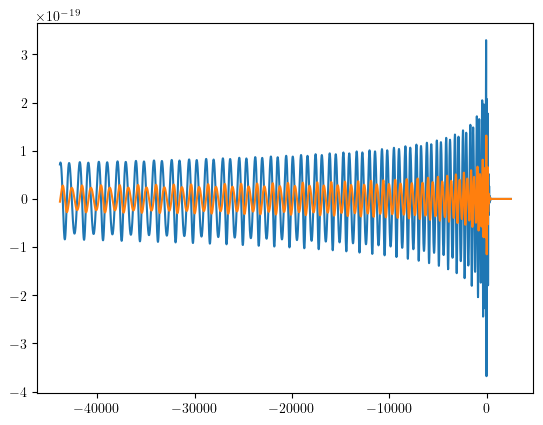

In [9]:
plt.plot(MasstoSecond(phenT.times, 1e6), hp1)
plt.plot(MasstoSecond(phenT.times, 1e6), hc1)

9.999999999992724

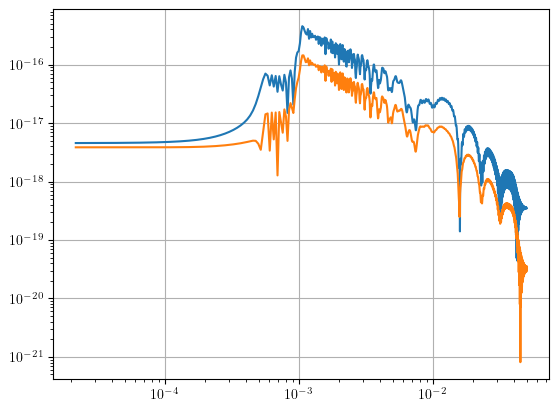

In [10]:
times_SI = MasstoSecond(phenT.times, 1e6)
ff, xf = FFT_window(hp1, 1./(times_SI[1] - times_SI[0]))
plt.loglog(ff, np.abs(xf))
ff, xf = FFT_window(hc1, 1./(times_SI[1] - times_SI[0]))
plt.loglog(ff, np.abs(xf))
plt.grid()
times_SI[1] - times_SI[0]

In [11]:
phenT.mode_array

[[2, 2],
 [2, 1],
 [3, 3],
 [4, 4],
 [5, 5],
 [2, -2],
 [2, -1],
 [3, -3],
 [4, -4],
 [5, -5]]

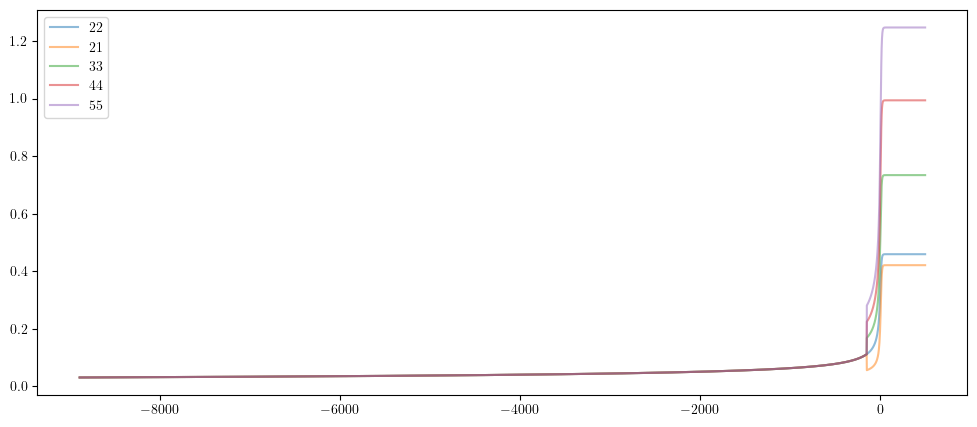

In [12]:
plt.figure(figsize=(12, 5))
for mode in phenT.mode_array:
    if mode[1] < 0: 
        continue
    else: 
        mode_str = str(mode[0])+str(mode[1])
        # print("mode string:", mode_str)
        plt.plot(phenT.times, phenT.phenT_classes[mode_str].pPhase.full_omega(times=phenT.times), label=mode_str, alpha=0.5)
plt.legend()

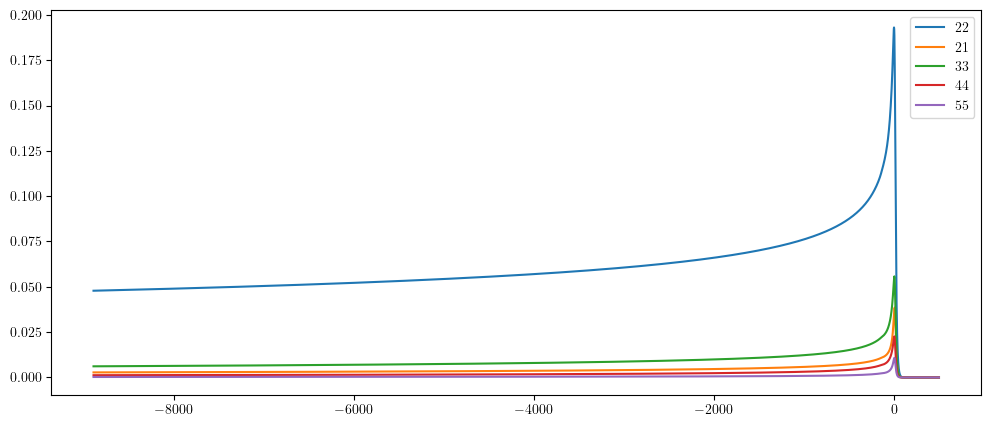

In [13]:
plt.figure(figsize=(12, 5))
for mode in phenT.mode_array:
    if mode[1] < 0: 
        continue
    else: 
        mode_str = str(mode[0])+str(mode[1])
        # print("mode string:", mode_str)
        plt.plot(phenT.times, np.abs(phenT.phenT_classes[mode_str].pAmp.full_amplitude(times=phenT.times)), label=mode_str)
plt.legend()

## Determine initial sampling rate 

100%|██████████| 1000/1000 [00:02<00:00, 481.61it/s]


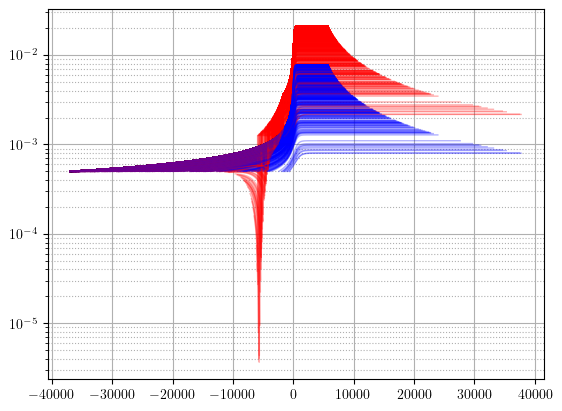

In [14]:
Mc0 = 1e6
Ntest = 1000
q_arr = np.random.uniform(0.01, 1., Ntest)
m1_arr = m1_Mc_q(Mc0, q_arr)
M_arr = m1_arr * (1. + q_arr)
s1_arr = np.zeros((Ntest, 3))
s2_arr = np.zeros((Ntest, 3))

for itest in tqdm(range(Ntest)):
    wf_params = dict(
        delta_t_sec=5., inclination=1.4, phiRef=0, total_mass=M_arr[itest], f_lower=5e-4, eta=eta_q(q_arr[itest]), s1=list(s1_arr[itest]), s2=list(s2_arr[itest]), f_ref=None
    )
    # print(wf_params)
    phenT = PhenomTHM(
        **wf_params, 
        cuda=False, 
        numba_ansatzaes=False, 
        )
    wf_time = MasstoSecond(phenT.times, M_arr[itest])
    wf_55_omega = SecondtoMass(phenT.phenT_classes["55"].pPhase.full_omega(times=phenT.times), M_arr[itest])
    wf_22_omega = SecondtoMass(phenT.phenT_classes["22"].pPhase.full_omega(times=phenT.times), M_arr[itest])
    plt.semilogy(wf_time, wf_55_omega / TWOPI, color="r", linewidth=1, alpha=0.3)
    plt.semilogy(wf_time, wf_22_omega / TWOPI, color="b", linewidth=1, alpha=0.3)
# plt.ylim(1e-3, 3e-1)
plt.grid(linestyle=":", which="minor")
plt.grid(linestyle="-", which="major")

## Test f_lower

In [15]:
Mc=1e6
Tobs=10*DAY/YEAR
f_lower = 1.75e-5 * (Mc / 1e6) ** (-5.0 / 8.0) * (Tobs / 10.0) ** (-3.0 / 8.0)
f_lower

0.00015996030372254942

## Adaptive time grid 

In [16]:
Mc0 = 1e6
q = np.random.uniform(0.01, 1.)
m1 = m1_Mc_q(Mc0, q)
M = m1 * (1. + q)
s1 = list(np.zeros(3))
s2 = list(np.zeros(3))
Tobs = 15 * DAY 
buffer_factor = 1.2
f_lower = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=Tobs*buffer_factor, m1=m1*MSUN, m2=m1*q*MSUN))

wf_params = dict(
    delta_t_sec=10. * Mc0 / 1e6, 
    inclination=np.arccos(np.random.uniform(-1, 1)), 
    phiRef=np.random.uniform(0, TWOPI), 
    total_mass=M, 
    f_lower=f_lower, 
    eta=eta_q(q), 
    s1=list(s1), 
    s2=list(s2), 
    f_ref=None
)
for k, v in wf_params.items():
    print(k, ":", v)
    
phenT = PhenomTHM(
    **wf_params, 
    cuda=False, 
    numba_ansatzaes=False, 
    )

delta_t_sec : 10.0
inclination : 2.1263810724129764
phiRef : 3.5181765173478
total_mass : 2318104.5350156915
f_lower : 0.0001279653975828071
eta : 0.24628897558758397
s1 : [0.0, 0.0, 0.0]
s2 : [0.0, 0.0, 0.0]
f_ref : None


(0.001, 0.026626557371482232)

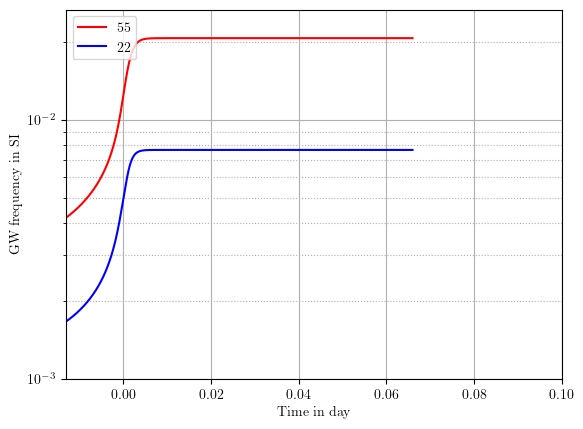

In [17]:
wf_time_SI = MasstoSecond(phenT.times, M)
wf_55_omega_SI = SecondtoMass(phenT.phenT_classes["55"].pPhase.full_omega(times=phenT.times), M)
wf_22_omega_SI = SecondtoMass(phenT.phenT_classes["22"].pPhase.full_omega(times=phenT.times), M)
plt.semilogy(wf_time_SI / DAY, wf_55_omega_SI / TWOPI, color="r", label="55")
plt.semilogy(wf_time_SI / DAY, wf_22_omega_SI / TWOPI, color="b", label="22")
plt.grid(linestyle=":", which="minor")
plt.grid(linestyle="-", which="major")
# plt.xlim(-1,)
plt.legend(loc="upper left")
plt.ylabel("GW frequency in SI")
plt.xlabel("Time in day")
plt.xlim(MasstoSecond(-100., M)/DAY, 0.1)
plt.ylim(1e-3,)

(0.005, 0.05900051933748657)

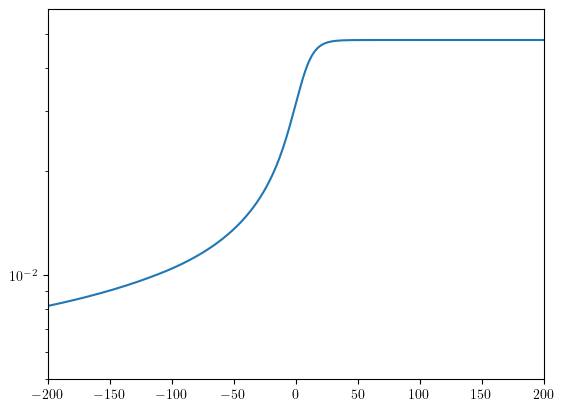

In [18]:
plt.semilogy(phenT.times, wf_22_omega_SI)
plt.xlim(-200, 200)
plt.ylim(5e-3,)

Text(0.5, 0, 'Time in day')

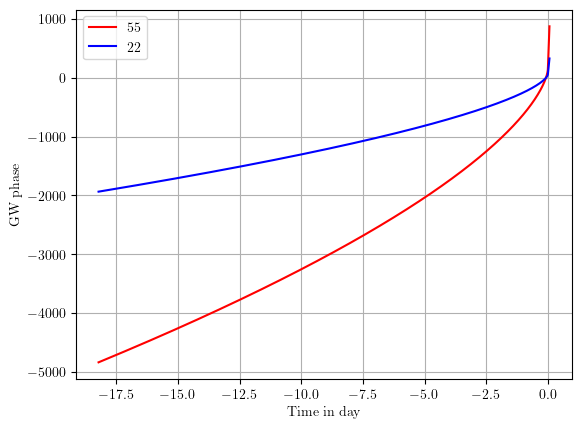

In [19]:
wf_55_phase = phenT.phenT_classes["55"].pPhase.full_phase(times=phenT.times)
wf_22_phase = phenT.phenT_classes["22"].pPhase.full_phase(times=phenT.times)
plt.plot(wf_time_SI / DAY, wf_55_phase, color="r", label="55")
plt.plot(wf_time_SI / DAY, wf_22_phase, color="b", label="22")
plt.grid(linestyle=":", which="minor")
plt.grid(linestyle="-", which="major")
# plt.xlim(-1,)
plt.legend(loc="upper left")
plt.ylabel("GW phase")
plt.xlabel("Time in day")

In [20]:
wf_time_SI = MasstoSecond(phenT.times, M)
wf_22_phase = phenT.phenT_classes["22"].pPhase.full_phase(times=phenT.times)

delta_Phi = 0.5
K = 1.1
delta_t_threshold = 2e5   

Phi_c = wf_22_phase[-1]

max_time_sample_idx1 = int((Phi_c - phenT.phenT_classes["22"].pPhase.full_phase(times=-100.)) / delta_Phi) 
time_sample_idx1 = np.arange(max_time_sample_idx1 + 1)
time_sample1_SI = np.interp(
    x = Phi_c - delta_Phi * (max_time_sample_idx1 - time_sample_idx1), 
    xp = wf_22_phase, 
    fp = wf_time_SI, 
)
print("number of time samples in the 1st segment:", max_time_sample_idx1)

max_omega2_SI = delta_Phi / (time_sample1_SI[1] - time_sample1_SI[0])
max_phase2 = phenT.phenT_classes["22"].pPhase.full_phase(times=SecondtoMass(time_sample1_SI[0], M))
max_time_sample_idx2 = int(np.log(delta_t_threshold / delta_Phi * np.sqrt(max_omega2_SI * wf_params["f_lower"] * TWOPI)) / np.log(K))
time_sample_idx2 = np.arange(max_time_sample_idx2 + 1)
time_sample2_SI = np.interp(
    x=max_phase2 - delta_Phi*(K ** (max_time_sample_idx2 - time_sample_idx2) - 1.) / np.log(K), 
    xp=wf_22_phase, 
    fp=wf_time_SI, 
)
print("number of time samples in the 2nd segment:", max_time_sample_idx2)

time_sample3_SI = np.arange(-Tobs*buffer_factor, time_sample2_SI[0], delta_t_threshold)
print("number of time samples in the 3rd segment:", time_sample3_SI.shape)

time_samples_SI = np.concatenate((time_sample3_SI, time_sample2_SI, time_sample1_SI))
print("total time sample shape:", time_samples_SI.shape)

number of time samples in the 1st segment: 579
number of time samples in the 2nd segment: 74
number of time samples in the 3rd segment: (0,)
total time sample shape: (655,)


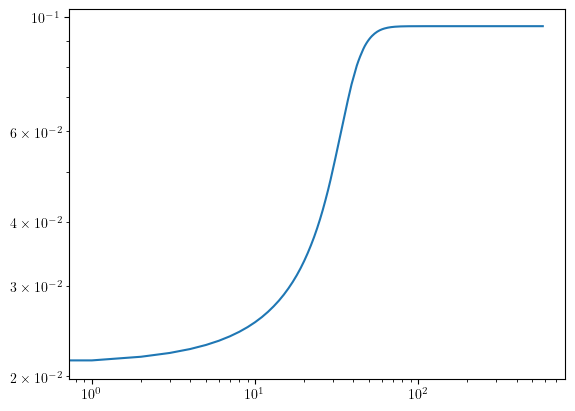

In [21]:
plt.loglog(1. / np.gradient(time_sample1_SI))

/var/folders/_f/d29qj88911xdzjc9ffs55hph0000gn/T/ipykernel_67150/3371505023.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1. / np.gradient(time_sample2_SI))


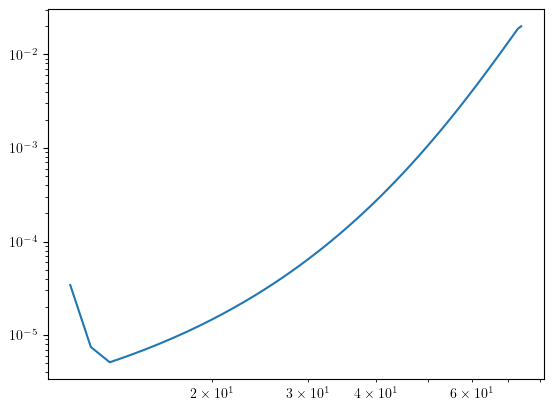

In [22]:
plt.loglog(1. / np.gradient(time_sample2_SI))

In [23]:
plt.loglog(1. / np.gradient(time_sample3_SI))

ValueError: Shape of array too small to calculate a numerical gradient, at least (edge_order + 1) elements are required.

In [ ]:
time_sample2_SI/DAY

array([-1.79217593e+01, -1.79217593e+01, -1.79217593e+01, -1.79217593e+01,
       -1.79217593e+01, -1.79217593e+01, -1.79217593e+01, -1.79217593e+01,
       -1.79217593e+01, -1.79217593e+01, -1.79217593e+01, -1.79217593e+01,
       -1.55481073e+01, -1.34229366e+01, -1.15923449e+01, -1.00151284e+01,
       -8.65588024e+00, -7.48417221e+00, -6.47385187e+00, -5.60243940e+00,
       -4.85060958e+00, -4.20174705e+00, -3.64156440e+00, -3.15777431e+00,
       -2.73980790e+00, -2.37857299e+00, -2.06624638e+00, -1.79609554e+00,
       -1.56232544e+00, -1.35994697e+00, -1.18466393e+00, -1.03277595e+00,
       -9.01095121e-01, -7.86874288e-01, -6.87745528e-01, -6.01667225e-01,
       -5.26878597e-01, -4.61860626e-01, -4.05302455e-01, -3.56072511e-01,
       -3.13193657e-01, -2.75821849e-01, -2.43227739e-01, -2.14780876e-01,
       -1.89936093e-01, -1.68221799e-01, -1.49229865e-01, -1.32606956e-01,
       -1.18047018e-01, -1.05284833e-01, -9.40904138e-02, -8.42642344e-02,
       -7.56330481e-02, -

/var/folders/_f/d29qj88911xdzjc9ffs55hph0000gn/T/ipykernel_62001/3673281695.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1. / np.gradient(time_samples_SI))


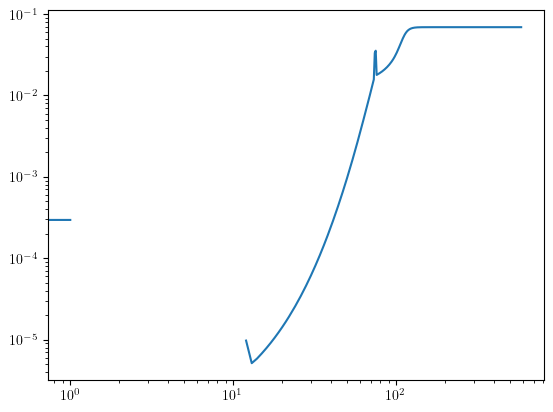

In [ ]:
plt.loglog(1. / np.gradient(time_samples_SI))

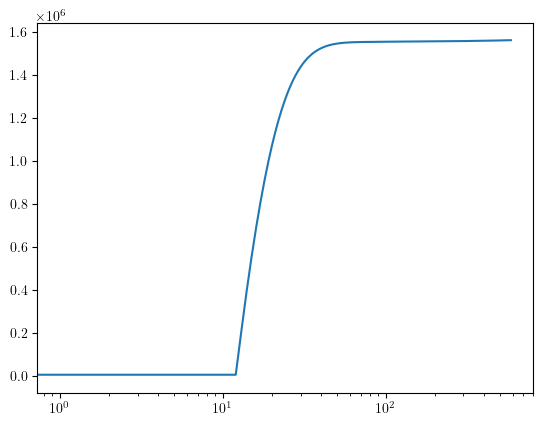

In [ ]:
plt.semilogx(time_samples_SI - time_samples_SI[0])

In [ ]:
for _ in tqdm(range(100)):
    wf_time_SI = MasstoSecond(phenT.times, M)
    wf_22_phase = phenT.phenT_classes["22"].pPhase.full_phase(times=phenT.times)

    delta_Phi = 0.5
    K = 1.1
    delta_t_threshold = 2e5   

    Phi_c = wf_22_phase[-1]

    max_time_sample_idx1 = int((Phi_c - phenT.phenT_classes["22"].pPhase.full_phase(times=-100.)) / delta_Phi) 
    time_sample_idx1 = np.arange(max_time_sample_idx1 + 1)
    time_sample1_SI = np.interp(
        x = Phi_c - delta_Phi * (max_time_sample_idx1 - time_sample_idx1), 
        xp = wf_22_phase, 
        fp = wf_time_SI, 
    )
    # print("number of time samples in the 1st segment:", max_time_sample_idx1)
    
    if time_sample1_SI[0] > -Tobs*buffer_factor:

        max_omega2_SI = delta_Phi / (time_sample1_SI[1] - time_sample1_SI[0])
        max_phase2 = phenT.phenT_classes["22"].pPhase.full_phase(times=SecondtoMass(time_sample1_SI[0], M))
        max_time_sample_idx2 = int(np.log(delta_t_threshold / delta_Phi * np.sqrt(max_omega2_SI * wf_params["f_lower"] * TWOPI)) / np.log(K))
        time_sample_idx2 = np.arange(max_time_sample_idx2 + 1)
        time_sample2_SI = np.interp(
            x=max_phase2 - delta_Phi*(K ** (max_time_sample_idx2 - time_sample_idx2) - 1.) / np.log(K), 
            xp=wf_22_phase, 
            fp=wf_time_SI, 
        )
        # print("number of time samples in the 2nd segment:", max_time_sample_idx2)
        
        if time_sample2_SI[0] > -Tobs*buffer_factor:

            time_sample3_SI = np.arange(-Tobs*buffer_factor, time_sample2_SI[0], delta_t_threshold)
            # print("number of time samples in the 3rd segment:", time_sample3_SI.shape)

            time_samples_SI = np.concatenate((time_sample3_SI, time_sample2_SI, time_sample1_SI))
            # print("total time sample shape:", time_samples_SI.shape)
        
        else: 
            time_samples_SI = np.concatenate((time_sample2_SI[time_sample2_SI>=-Tobs*buffer_factor], time_sample1_SI))
        
    else: 
        time_samples_SI = time_sample1_SI[time_sample1_SI>=-Tobs*buffer_factor]

100%|██████████| 100/100 [00:02<00:00, 49.91it/s]


## A simpler one 

In [24]:
Mc0 = 1e6
q = np.random.uniform(0.01, 1.)
m1 = m1_Mc_q(Mc0, q)
M = m1 * (1. + q)
s1 = list(np.zeros(3))
s2 = list(np.zeros(3))
Tobs = 90 * DAY 
buffer_factor = 1.2
f_lower = max(5e-5, SimInspiralChirpStartFrequencyBound(tchirp=Tobs*buffer_factor, m1=m1*MSUN, m2=m1*q*MSUN))

wf_params = dict(
    delta_t_sec=10. * Mc0 / 1e6, 
    inclination=np.arccos(np.random.uniform(-1, 1)), 
    phiRef=np.random.uniform(0, TWOPI), 
    total_mass=M, 
    f_lower=f_lower, 
    eta=eta_q(q), 
    s1=list(s1), 
    s2=list(s2), 
    f_ref=None
)
for k, v in wf_params.items():
    print(k, ":", v)
    
phenT = PhenomTHM(
    **wf_params, 
    cuda=False, 
    numba_ansatzaes=False, 
    )

delta_t_sec : 10.0
inclination : 1.8744933509763744
phiRef : 5.32205441871509
total_mass : 4883899.443685343
f_lower : 6.535605528205507e-05
eta : 0.07113043709893203
s1 : [0.0, 0.0, 0.0]
s2 : [0.0, 0.0, 0.0]
f_ref : None


In [46]:
for _ in tqdm(range(1)):
    lower_time_limit_SI = -Tobs*buffer_factor

    interp_idx = np.where(phenT.times > -150.)[0]
    wf_time_SI = MasstoSecond(phenT.times[interp_idx], M)
    wf_22_phase = phenT.phenT_classes["22"].pPhase.full_phase(times=phenT.times[interp_idx])

    delta_Phi = 0.5
    delta_t_threshold = 2e5   

    Phi_c = wf_22_phase[-1]

    max_time_sample_idx1 = int((Phi_c - phenT.phenT_classes["22"].pPhase.full_phase(times=-100.)) / delta_Phi) 
    time_sample_idx1 = np.arange(max_time_sample_idx1 + 1)
    time_sample1_SI = np.interp(
        x = Phi_c - delta_Phi * (max_time_sample_idx1 - time_sample_idx1), 
        xp = wf_22_phase, 
        fp = wf_time_SI, 
    )
    print("number of time samples in the 1st segment:", max_time_sample_idx1)

    if time_sample1_SI[0] > lower_time_limit_SI:

        min_delta_t_SI = time_sample1_SI[1] - time_sample1_SI[0]
        a_coef = 1. 
        b_coef = np.log(min_delta_t_SI)
        max_time_sample_idx2 = int((np.log(delta_t_threshold / a_coef) - b_coef) / a_coef)
        time_sample_idx2 = np.arange(max_time_sample_idx2 + 1)

        time_sample2_SI = (time_sample1_SI[0] - np.exp(a_coef * time_sample_idx2 + b_coef))[::-1]
        print("number of time samples in the 2nd segment:", max_time_sample_idx2)
        
        if time_sample2_SI[0] > lower_time_limit_SI:

            time_sample3_SI = np.arange(lower_time_limit_SI, time_sample2_SI[0], delta_t_threshold)
            print("number of time samples in the 3rd segment:", len(time_sample3_SI))

            time_samples_SI = np.concatenate((time_sample3_SI, time_sample2_SI, time_sample1_SI))
            print("total time sample shape:", len(time_samples_SI))
            
        else: 
            time_samples_SI = np.concatenate((time_sample2_SI[time_sample2_SI>=lower_time_limit_SI], time_sample1_SI))
        
    else: 
        time_samples_SI = time_sample1_SI[time_sample1_SI>=lower_time_limit_SI]
        
    time_samples_SI.shape 

100%|██████████| 1/1 [00:00<00:00, 1144.11it/s]

number of time samples in the 1st segment: 440
number of time samples in the 2nd segment: 7
number of time samples in the 3rd segment: 47
total time sample shape: 496


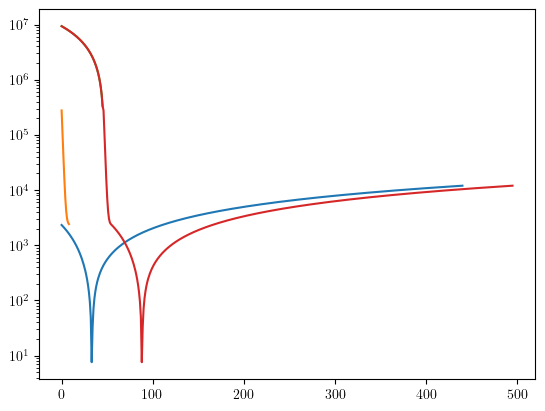

In [38]:
plt.semilogy(np.abs(time_sample1_SI))
plt.semilogy(np.abs(time_sample2_SI))
plt.semilogy(np.abs(time_sample3_SI))
plt.semilogy(np.abs(time_samples_SI))

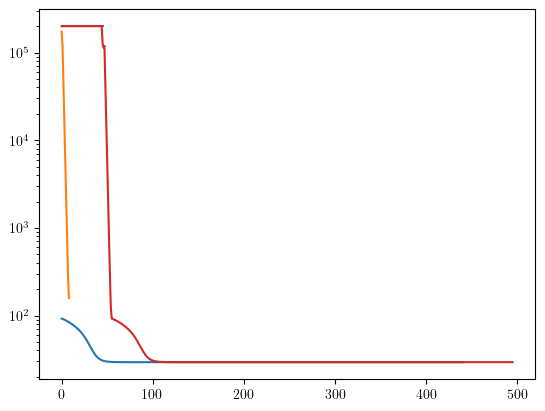

In [35]:
plt.semilogy(np.gradient(time_sample1_SI))
plt.semilogy(np.gradient(time_sample2_SI))
plt.semilogy(np.gradient(time_sample3_SI))
plt.semilogy(np.gradient(time_samples_SI))

## Settings 

In [ ]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

## Initialize response models 

### TDI-on-the-fly

In [ ]:
fast_response_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring=TDIFlyGB.X2_strings, 
    tcb_times=tcb_times.copy(), 
    Nsparse=1024, 
    # Nsparse=512,
    drop_points=1000, 
    use_gpu=False, 
)



### general TDI response 

In [ ]:
gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=TDIFlyGB.X2_strings, 
    tcb_times=tcb_times.copy(), 
    use_gpu=False, 
    drop_points=1000,
    linear_interp=False, 
    return_eta=False, 
)

KeyboardInterrupt: 

## Source parameters 

In [ ]:
GB_params = {
    "A": 1.52072235e-21, 
    # "f0": 0.005, 
    # "fdot0": 8.15e-16, 
    "f0": 0.0161367, 
    "fdot0": 3.34732748e-13, 
    "phase0": 3.42918555, 
    "inclination": 1.5166699, 
    "longitude": 1.7686, 
    "latitude": 0.10127302, 
    "psi": 0.94753924
    }

## Test speed 

In [ ]:
for _ in tqdm(range(10)):
    fas = fast_response_generator(
        GB_params, 
        domain="time"
        )
fas.shape 

100%|██████████| 10/10 [00:01<00:00,  7.07it/s]


(3155814,)

In [ ]:
for _ in tqdm(range(1)):
    fas_fd = fast_response_generator(
        parameters=GB_params, 
        domain="frequency"
        )
fas_fd.shape 

100%|██████████| 1/1 [00:00<00:00, 398.77it/s]


(1024,)

In [ ]:
gen = gb_response_generator(parameters=GB_params, waveform_generator=gb_waveform_generator)
gen.shape 

(3155814,)

## Show sparse sampled response 

In [ ]:
res = fast_response_generator.sparse_fasponse
Re_res = np.real(res[0])
Im_res = np.imag(res[0])
Amp_res = np.abs(res[0])
Arg_res = np.angle(res[0])

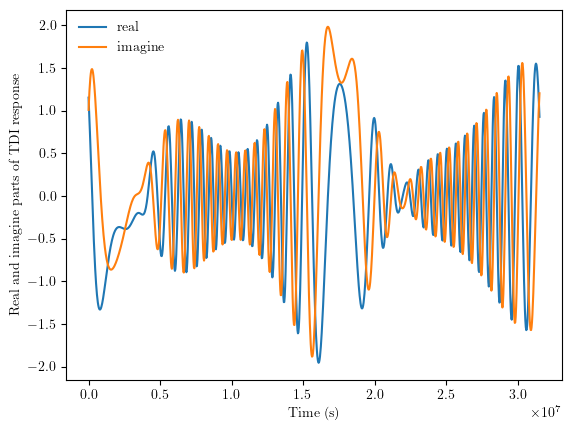

In [ ]:
plt.plot(fast_response_generator.sparse_times, Re_res, label="real")
plt.plot(fast_response_generator.sparse_times, Im_res, label="imagine")
plt.xlabel("Time (s)")
plt.ylabel("Real and imagine parts of TDI response")
plt.legend(loc="upper left", frameon=False)

Text(0.5, 1.0, 'response amplitude')

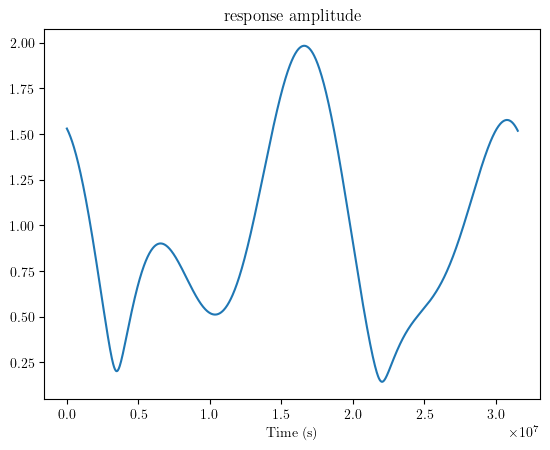

In [ ]:
plt.plot(fast_response_generator.sparse_times, Amp_res)
plt.xlabel("Time (s)")
plt.title("response amplitude")

Text(0.5, 1.0, 'response phase')

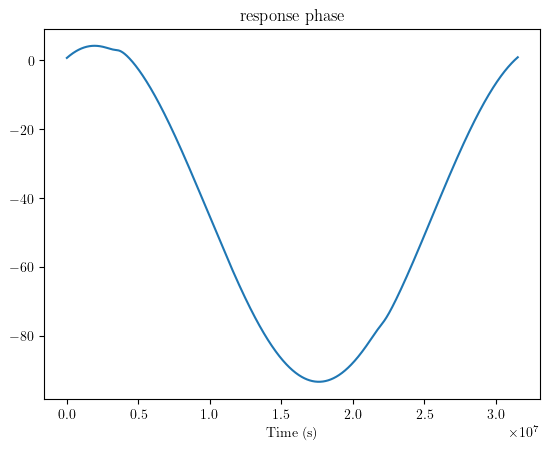

In [ ]:
plt.plot(fast_response_generator.sparse_times, np.unwrap(Arg_res))
plt.xlabel("Time (s)")
plt.title("response phase")

## Validate accuracy 

(31458130.0, 31558130.0)

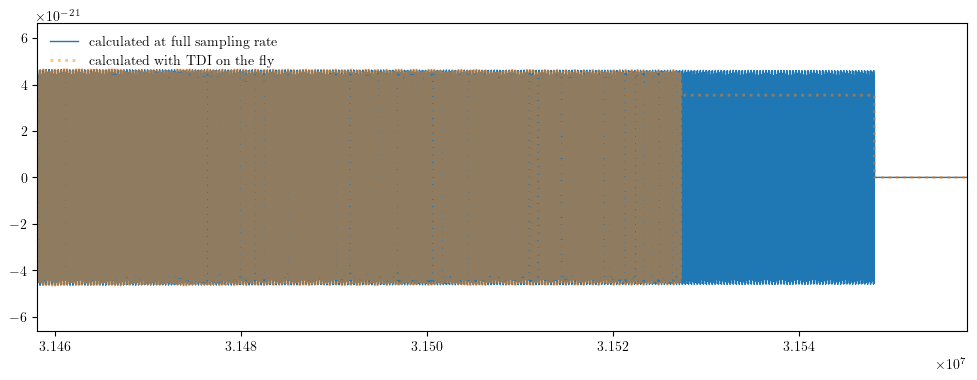

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(tcb_times, gen, linewidth=1, zorder=1, label="calculated at full sampling rate")
plt.plot(tcb_times, fas, linestyle=":", linewidth=2, label="calculated with TDI on the fly", alpha=0.5)

# plt.plot(tcb_times, gen - fas, label="difference")

plt.legend(loc="upper left", frameon=False)
plt.xlim(tcb_times[-1]-100000, tcb_times[-1])

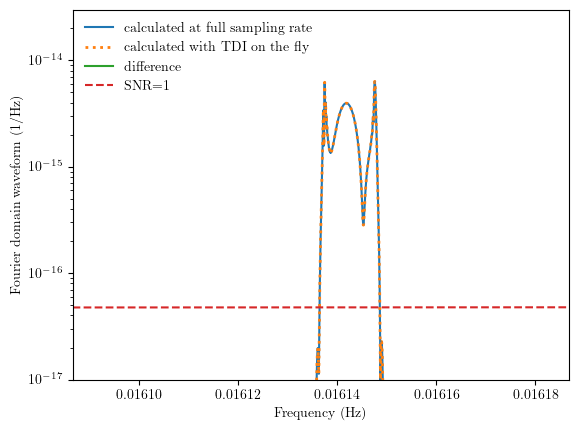

In [ ]:
ff, xf = FFT_window(gen, 1./dt, window_type="tukey", window_args_dict=dict(alpha=0.1))
plt.semilogy(ff, np.abs(xf), label="calculated at full sampling rate")
ff, xf = FFT_window(fas, 1./dt, window_type="tukey", window_args_dict=dict(alpha=0.1))
plt.semilogy(ff, np.abs(xf), label="calculated with TDI on the fly", linestyle=":", linewidth=2)
ff, xf = FFT_window(gen - fas, 1./dt, window_type="tukey", window_args_dict=dict(alpha=0.1))
plt.semilogy(ff, np.abs(xf), label="difference")
psdfunc = TDIPSDs()
plt.semilogy(ff, np.sqrt(psdfunc.PSD_X2(ff) * Tobs / 4.), linestyle="--", label="SNR=1")
# plt.xlim(GB_params["f0"] - 5e-6, GB_params["f0"] + 5e-6)
plt.xlim(GB_params["f0"] - 5e-5, GB_params["f0"] + 5e-5)
plt.ylim(1e-17,)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier domain waveform (1/Hz)")
plt.legend(loc="upper left", frameon=False)

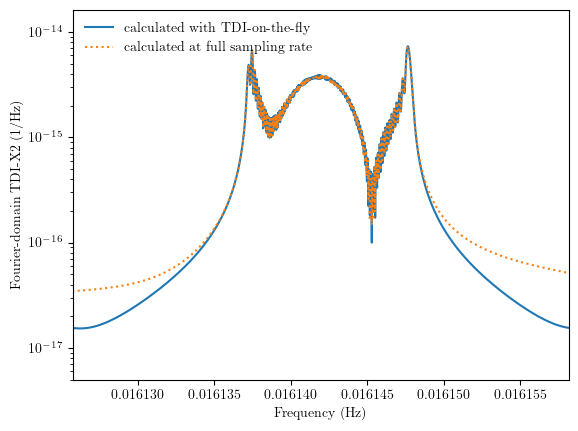

In [ ]:
cut_freq = 1. / fast_response_generator.Tobs * (np.arange(fast_response_generator.Nsparse)+fast_response_generator.start_idx[0])
plt.semilogy(cut_freq, np.abs(fas_fd), label="calculated with TDI-on-the-fly")
ff, xf = FFT_window(
    gen, 
    1./dt, 
    # window_type="tukey", 
    # window_args_dict=dict(alpha=0.1)
    )
plt.semilogy(ff, np.abs(xf), label="calculated at full sampling rate", linestyle=":")
# plt.semilogy(cut_freq, np.abs(fas_fd - xf[np.where(ff>=cut_freq[0])[0][0]:np.where(ff<=cut_freq[-1])[0][-1]+1]), label="difference")

psdfunc = TDIPSDs()
# plt.semilogy(ff, np.sqrt(psdfunc.PSD_X2(ff) * Tobs / 4.), linestyle="--", label="SNR=1")
# plt.xlim(GB_params["f0"] - 5e-6, GB_params["f0"] + 5e-6)
# plt.xlim(GB_params["f0"] - 5e-5, GB_params["f0"] + 5e-5)
plt.xlim(cut_freq[0], cut_freq[-1])
plt.ylim(5e-18,)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier-domain TDI-X2 (1/Hz)")
plt.legend(loc="upper left", frameon=False)
